In [58]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import dask
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import calendar

# Domain & Period

In [59]:
iyear=1960
fyear=2025
dom='HK'
latS,latN,lonW,lonE = coord_domain(dom)

# Elevation data

In [60]:
elev = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/santolam/gmted/gmted_on_era5_grid.nc')['elevation']
elev = field_dom(elev,dom)

# Seasonal Mean data

In [61]:
tp = xr.open_dataset('/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/vimd_monthly_era5_1940-2025_NH_025x025.nc')['vimd']

tp=tp.rename({'valid_time': 'time'})
tp=tp.rename({'longitude': 'lon'})
tp=tp.rename({'latitude': 'lat'})

tp = field_dom(tp, dom)
tp = tp.sel(time=slice(str(iyear),str(fyear)))

In [62]:
seasons = ["DJFM","AM","JJAS","ON"]

tp_dict = {}

for season in seasons:
    tp_season = clim(tp, season=season, imon=1, iyr=iyear, fmon=12, fyr=fyear)
    tp_dict[season] = tp_season

5


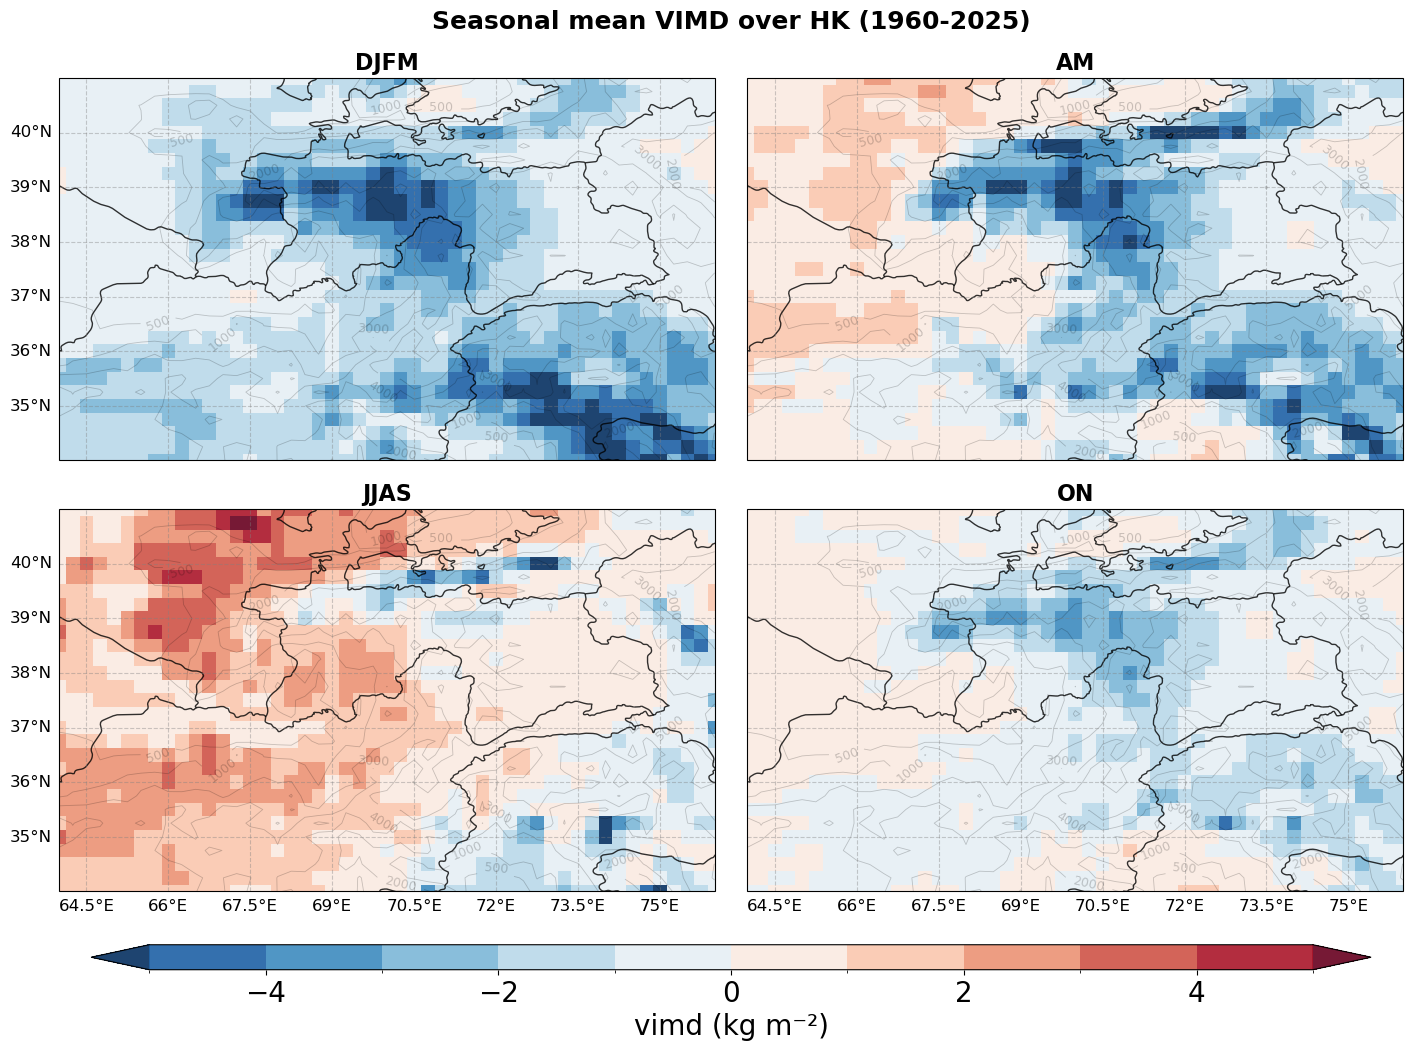

In [63]:
#==================== Color grading ============================

step = 1
vmax = 5
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("RdBu_r", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = tp_dict[season]
       
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto", alpha=0.9
       )
        
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.02, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("vimd (kg m⁻²)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.05, wspace=0.05, hspace=-0.1)
plt.suptitle(
    f"Seasonal mean VIMD over HK ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

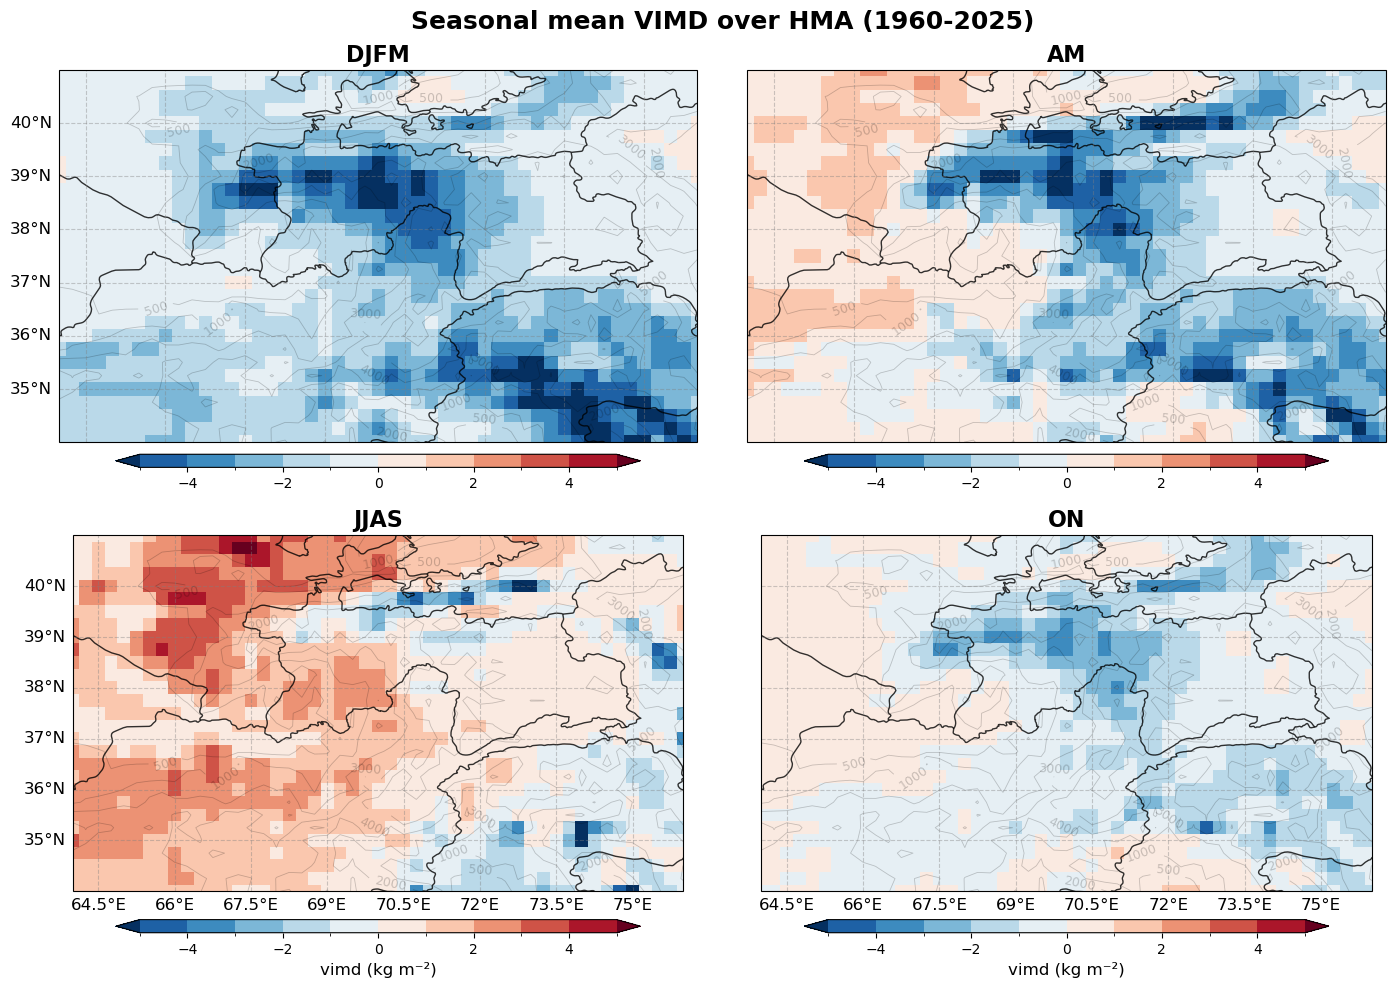

In [36]:
# to have a colorbar for each season

vmax_dict = {
    "DJFM": 5,
    "AM": 5,
    "JJAS": 5,
    "ON": 5
}

step_dict = {
    "DJFM": 1,
    "AM": 1,
    "JJAS": 1,
    "ON": 1
}

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = tp_dict[season]

    # color grading
    vmax = vmax_dict[season]
    step = step_dict[season]
    levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
    cmap = plt.get_cmap("RdBu_r", len(levels)-1+2)
    norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')
    
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )

    #Colorbar for each season
    if i in [2,3]:
        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.07, shrink=0.8, fraction=0.05, aspect=40, extend='both')
        cbar.set_label("vimd (kg m⁻²)", fontsize=12)
    else:
        cbar = fig.colorbar(im, ax=ax, orientation="horizontal", pad=0.03, shrink=0.8, fraction=0.05, aspect=40, extend='both')
    cbar.ax.tick_params(labelsize=10)
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.05, wspace=0.05, hspace=0.15)
plt.suptitle(
    f"Seasonal mean VIMD over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

# Seasonal Trends data

In [55]:
seasons = {"DJFM": [12,1,2,3], 
           "AM": [4,5], 
           "JJAS": [6,7,8,9], 
           "ON": [10,11]}

trend_dict = {}
p_dict={}

for season in seasons:
    tp_season = seasonal_selection2(tp, seasons[season], iyear, fyear)
    par = trend_vect(tp_season.time, tp_season, dim='time')
    trend=par[0]*10; p=par[3]
    trend_dict[season]=trend
    p_dict[season]=p

0.5


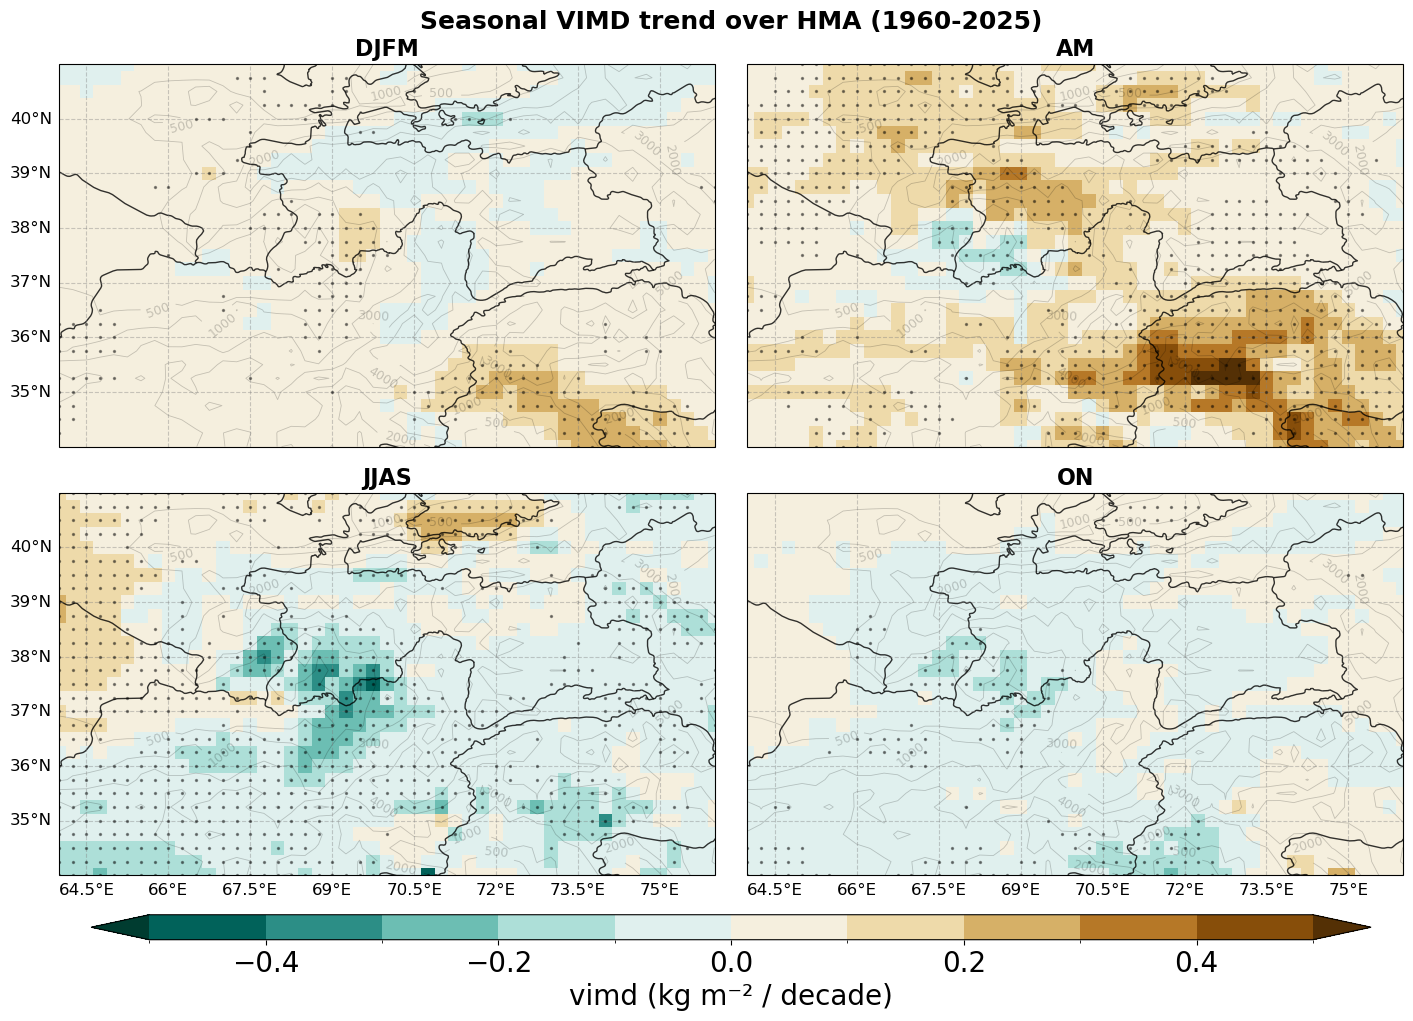

In [45]:
seasons = ['DJFM','AM','JJAS','ON']

#==================== Color grading ============================

step = 0.1
vmax = 0.5
print(vmax)
levels = np.arange(-vmax, vmax + step, step)
cmap = plt.get_cmap("BrBG_r", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = trend_dict[season]
    
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto"
       )

    sig = p_dict[season] < 0.05   
    step = 1
    lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("vimd (kg m⁻² / decade)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.08, wspace=0.05, hspace=-0.05)
plt.suptitle(
    f"Seasonal VIMD trend over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()

# Pourcentage trend

In [56]:
seasons = ["DJFM","AM","JJAS","ON"]

trend_percentage_dict = {}

for season in seasons:
    mean = tp_dict[season]
    trend = trend_dict[season]
    
    trend_percentage_dict[season] = (trend_dict[season] / np.abs(tp_dict[season])).where(tp_dict[season] != 0) * 100

100


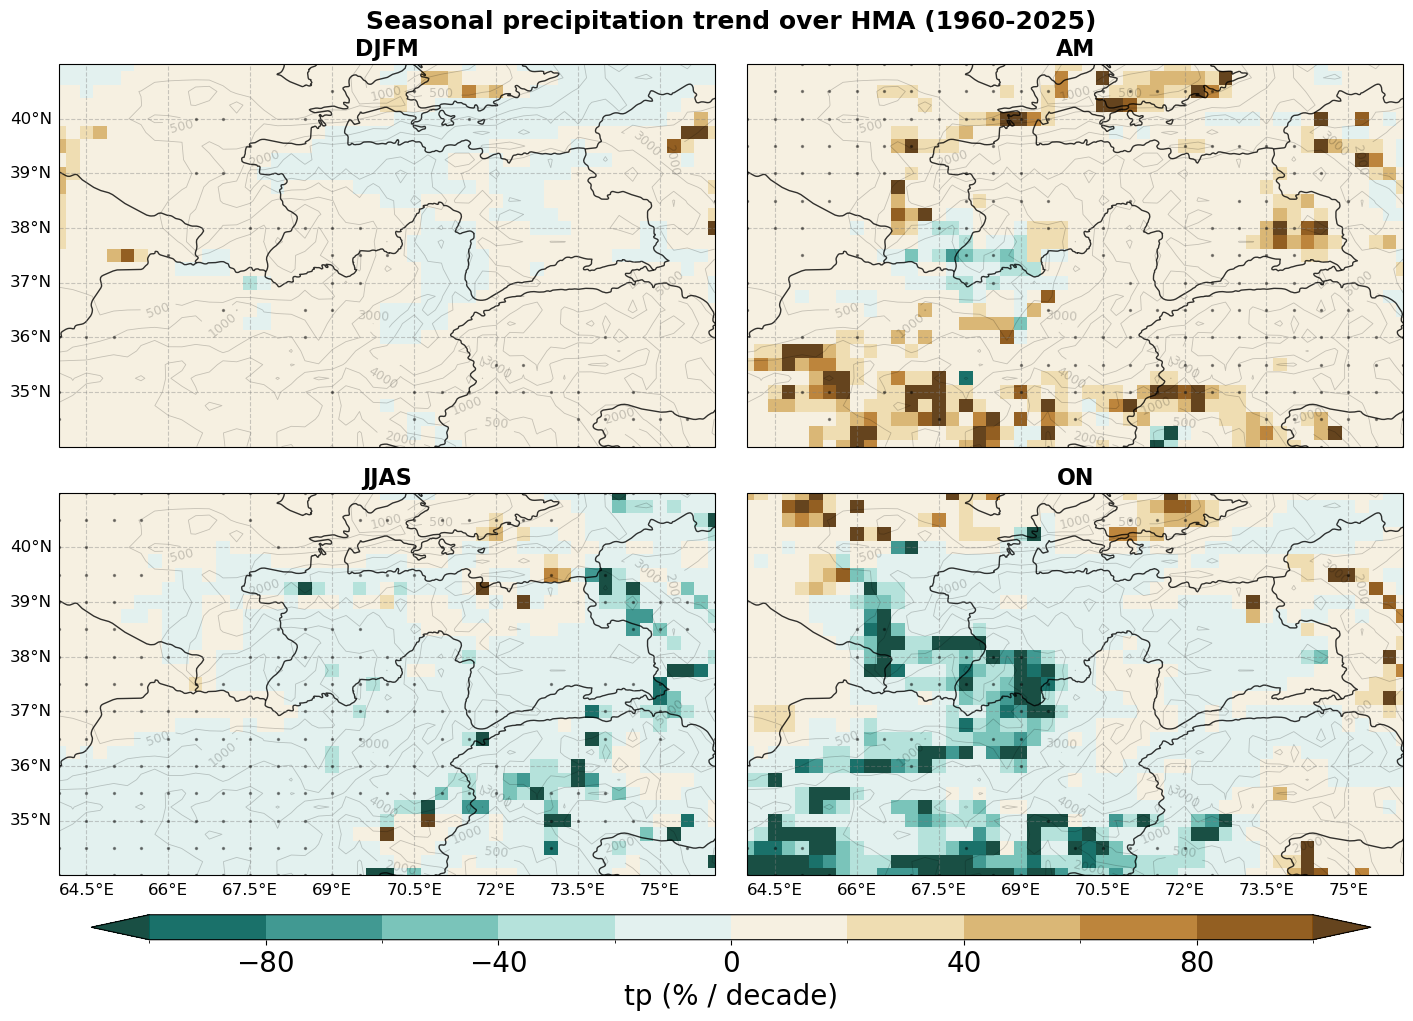

In [57]:
seasons = ['DJFM','AM','JJAS','ON']

#==================== Color grading ============================

step = 20
vmax = 100
print(vmax)
levels = np.linspace(-vmax, vmax, int(2*vmax/step)+1)
cmap = plt.get_cmap("BrBG_r", len(levels)-1+2)
norm = mcolors.BoundaryNorm(levels, ncolors=cmap.N, extend='both')

#===================== Plot each season ==================

fig, axes = plt.subplots(
    2, 2,
    figsize=(16, 10),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten()

for i, ax in enumerate(axes):
    season = seasons[i]
    data_model = trend_percentage_dict[season]
    
    im = ax.pcolormesh(
           data_model['lon'], data_model['lat'], data_model,
           transform=ccrs.PlateCarree(),
           cmap=cmap,
           norm=norm,
           shading="auto", alpha =0.9
       )

    sig = p_dict[season] < 0.05   
    step = 2
    lon_sig, lat_sig = data_model['lon'].values, data_model['lat'].values
    lon_grid, lat_grid = np.meshgrid(lon_sig, lat_sig)
    ax.scatter(lon_grid[::step, ::step][sig[::step, ::step]],lat_grid[::step, ::step][sig[::step, ::step]],
           color='black', s=2, marker='o', transform=ccrs.PlateCarree(), zorder=5, alpha=0.4)
    
    ax.set_extent([lonW, lonE, latS, latN], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE, linewidth=1, alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle="-", alpha=0.8)

    SH = ax.contour(
        elev.longitude,
        elev.latitude,
        elev,
        levels=[500,1000,2000,3000,4000,5000,6000,7000],
        colors="k",
        linewidths=0.6,
        alpha=0.2,
        transform=ccrs.PlateCarree()
    )
    ax.clabel(SH, inline=True, fontsize=9, fmt="%d")
    
    ax.set_title(season, fontsize=16, weight="bold")

    gl = ax.gridlines(crs=ccrs.PlateCarree(),draw_labels=True,linewidth=0.8,color="gray",alpha=0.4,linestyle="--")
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (i % 2 == 0)
    gl.bottom_labels = (i >= 2) 
    gl.xlabel_style = {"size": 12}
    gl.ylabel_style = {"size": 12}

#==================== Bar color ============================

cbar_ax = fig.add_axes([0.1, 0.05, 0.8, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal", extend='both')
cbar.set_label("tp (% / decade)", fontsize=20)
cbar.ax.tick_params(labelsize=20)

#==================== Final adjustments ============================

fig.subplots_adjust(left=0.08, right=0.92, top=0.96, bottom=0.08, wspace=0.05, hspace=-0.05)
plt.suptitle(
    f"Seasonal precipitation trend over HMA ({iyear}-{fyear})",
    fontsize=18,
    weight="bold"
)

plt.show()